## ddHodge workflow

## Setup

### Load packages and helper functions

In [ ]:
using GLMakie, FreqTables, DataFrames
using LinearAlgebra, Graphs, NearestNeighbors
using StatsBase: mean, median, cor

# Helper functions

# To write the results back to h5ad (if required)
@isdefined(H5Adh) || include("../tools/H5ADHelper.jl")

# clipping for visualization
function clip(x,p=[0.01,0.99])
    position(p) = Int.(round.(length(x)*p))
    p = length(p)==1 ? [p,1-p] : p
    lower, upper = position.(p)
    xs = sort(x)
    clamp.(x,xs[lower],xs[upper])
end

clipmax(x;p=0.05) = maximum(abs.(clip(x,p)))

### Set graphic theme

In [40]:
forPrint = false # white background and SVG
if forPrint
    # for figure
    import CairoMakie
    CairoMakie.activate!(type="svg")
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use
    GLMakie.activate!(px_per_unit=1)
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)

## Load anndata

In [41]:
import Muon
#h5file = "../data/scvelo_vasa_all.h5ad"
h5file = "../data/scvelo_vasa_all_rankgenes.h5ad"
adata = Muon.readh5ad(h5file,backed=false)

AnnData object 46124 ✕ 2000

In [42]:
npc = 40
X = adata.obsm["X_pca"][:,1:npc]'
V = adata.obsm["velocity_pca"][:,1:npc]'
loadings = adata.varm["PCs"][:,1:npc]
# for visualization
pts = Point2f.(eachrow(adata.obsm["X_umap"]))
N = size(X,2)

46124

In [43]:
X_viz = adata.obsm["X_umap"]'
V_viz = adata.obsm["velocity_umap"]'
kdtreeviz = KDTree(X_viz)
# Epanechnikov quadratic kernel
kernel(t) = 3/4*(1-t^2) # defined for 0<=t<=1
#kernel(t;σ=1) = gauss(t,μ=0,σ=0.5)

# K-nn value
function knnvalue(x;value,k=30,ϵ=0.5)
    i, d = knn(kdtreeviz, x, k, true)
    (d[1] > ϵ) && return(fill(NaN,length(value[1])))
    v = value[i]
    w = kernel.(d/d[k])
    v'*(w/sum(w))
end

knnvf(x,y;k=10,ϵ=0.5) = Point2f(vec(knnvalue([x,y];value=eachcol(V_viz),k=k,ϵ=ϵ)))

interval = x -> minimum(1.1x)..maximum(1.1x)
exts = interval.([get.(pts,i,missing) for i in 1:2])
function stream!(ax;k=10,ϵ=0.5,gridsize=(50,50),color=:white,arrow_size=10)
    vf = (x,y) -> knnvf(x,y;k=k,ϵ=ϵ)
    streamplot!(ax,vf,exts...,arrow_size=arrow_size,linewidth=1.8,colormap=[(color,0.6)],gridsize=gridsize)
end

stream! (generic function with 1 method)

## Clusters

### Set main annotation and colors

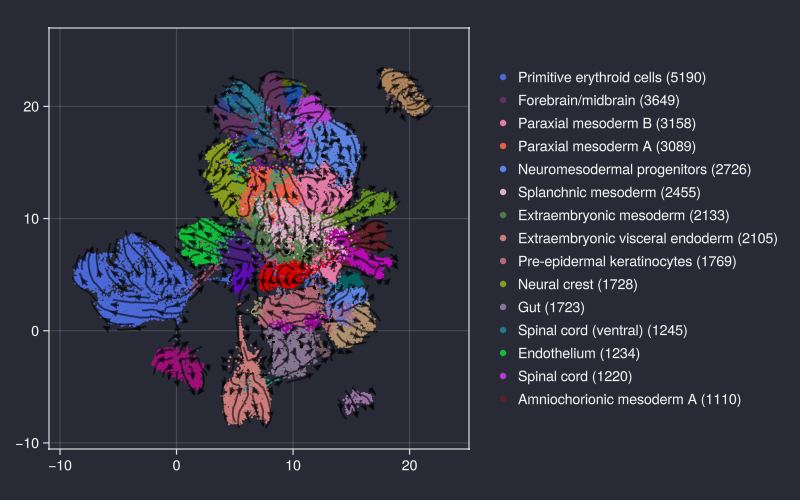

In [44]:
#anno = :major_trajectory
#anno = :majority_voting
anno = :qiu2022
cats = string.(adata.obs[!,anno])
lvs = levels(cats)
lvfreq = sort(freqtable(cats),rev=true)
#cname = :glasbey_hv_n256
#cname = :glasbey_bw_minc_20_minl_30_n256 # nice for darktheme
cname = :glasbey_bw_minc_20_maxl_70_n256 # :tab10
cpal = Dict(zip(lvs,resample_cmap(cname,max(length(lvs),10))))

let
    lvs = names(lvfreq[1:min(15,length(levels(cats)))])[1] # show top 10 freq.
    lvs = lvs[lvfreq[lvs] .>= 2] # at least 2 cells
    labels = [string(lv)*" ($(lvfreq[lv]))" for lv in lvs]
    fig = Figure(size=(800,500))
    ax = Axis(fig[1,1],aspect=1)
    scatter!(ax, pts, markersize=3, color=[cpal[c] for c in cats],rasterize=2)
    Legend(fig[1,2],[MarkerElement(marker=:circle, color=cpal[p]) for p in lvs],labels,nbanks=1)
    stream!(ax,gridsize=(50,50),color=:black,arrow_size=10)
    fig
end

### Show stage distribution

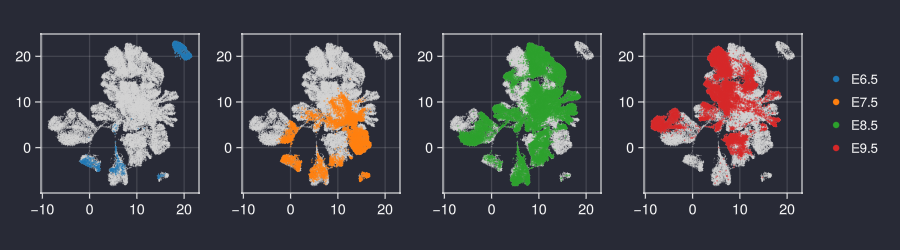

In [45]:
let
    cats = adata.obs.stage
    lvs = levels(adata.obs.stage)
    ppal = Dict(zip(lvs,resample_cmap(:tab10,10)))
    pcols = [get(ppal,c,:lightgrey) for c in cats]
    fig = Figure(size=(900,250),)
    axs = [Axis(fig[1,i],aspect=1) for i in 1:length(lvs)]
    for i in 1:length(lvs)
        pshow = cats .== lvs[i]
        scatter!(axs[i],pts,markersize=1,color=(:lightgrey,0.6),rasterize=2)
        scatter!(axs[i],pts[pshow],markersize=2,color=(ppal[lvs[i]],0.6),rasterize=2)
    end
    Legend(fig[1,length(lvs)+1],[MarkerElement(marker=:circle, color=ppal[p]) for p in lvs],lvs,labelsize=13)
    fig
end

In [46]:
adata.var.velocity_gamma

2000-element Vector{Float32}:
 0.12316961
 0.0437431
 1.8030267
 0.076623686
 0.6701905
 0.34696323
 0.09748688
 1.2714486
 4.2064214
 0.018133473
 0.1466942
 0.14692362
 0.26608923
 ⋮
 1.518992
 0.01107233
 0.0
 0.0
 0.72034717
 0.3461548
 0.02643944
 0.57213604
 0.40683186
 0.11747571
 0.82492274
 0.0

## ddHodge workflow

### Set k, local dim. and regularization params.

In [47]:
using ddHodge

struct Params
    k::Int
    d::Int
    λ::AbstractFloat
    ϵ::AbstractFloat
end

par = Params(12,4,0.1,1.0)

Params(12, 4, 0.1, 1.0)

### Graph construction

In [48]:
@time g, kdtree, = kNNGraph(X,par.k) # slow for higher dimension

  9.688166 seconds (1.45 M allocations: 75.206 MiB)


(SimpleGraph{Int64}(423805, [[315, 316, 363, 409, 562, 754, 805, 819, 825, 1035, 1080, 3034, 3378, 5064, 10690, 37849], [30, 68, 117, 120, 132, 143, 164, 172, 292, 320, 411, 506, 557, 783, 1067, 1079, 1097, 1116], [46, 83, 127, 138, 167, 190, 335, 407, 574, 892, 1247, 1255], [16, 18, 40, 123, 129, 149, 154, 184, 380, 412, 483, 508, 669, 1486, 8367, 19016], [9, 31, 35, 63, 73, 82, 88, 91, 105, 115, 124, 285, 474, 960, 1064, 1249], [96, 116, 147, 159, 207, 432, 963, 972, 1003, 1017, 1029, 1051, 1069, 1277], [46, 86, 94, 132, 170, 498, 684, 786, 1011, 1062, 1079, 1149, 1180, 1183, 1200, 1208, 1248, 1264], [17, 38, 57, 67, 74, 110, 112, 119, 120, 136  …  1083, 1088, 1151, 1167, 1168, 1171, 1191, 1210, 1255, 1264], [5, 31, 35, 58, 73, 88, 105, 115, 185, 217  …  443, 469, 485, 610, 1064, 1099, 1117, 1162, 1249, 1252], [18, 49, 149, 154, 280, 300, 395, 412, 791, 904, 1024, 1093, 1211, 1486, 3542, 5938]  …  [14776, 21268, 21389, 22631, 23342, 23887, 24934, 26018, 31029, 32373, 38724, 40312, 43

### Run ddHodge

In [49]:
import CUDA
CUDA.@time ddh = ddHodgeWorkflow(
    g, X, V, rdim=par.d, λ=par.λ, ϵ=par.ϵ, ssa=true, # these are essential
    ssart=1, krytol=1e-32, useCUDA=true # these are optional
)

[ Info: (1/4) Potential estimation
[ Info: ... done in 5.645 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 0.5621925177853022
[ Info: ... done in 15.348 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 5.575 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 0.5612534066374866
[ Info: ... done in 9.993 sec.


 36.712053 seconds (98.76 M CPU allocations: 21.192 GiB, 18.98% gc time) (90.17 k GPU allocations: 10.119 GiB, 0.90% memmgmt time)


:::ddHodge::: values over graph {46124, 423805}, dimensions: 40 -> 4 (ssa: on)

### Reflect the results to h5ad

In [50]:
let featurestowrite = [:u,:div,:rot,:vgrass]
    [adata.obs[!,"ddh_$(ft)"] = getfield(ddh,ft) for ft in featurestowrite]
    H5Adh.insertddh(h5file,ddh,keys=featurestowrite) # save if needed
end

## Check results

In [51]:
using JLD2
fucci = load("../data/scvelo_fucci_pca_k12_d4.jld2")["ddh"]

:::ddHodge::: values over graph {1152, 10926}, dimensions: 40 -> 4 (ssa: on)

In [52]:
sum(abs2.(ddh.w)),sum(abs2.(ddh.d0*ddh.u)) + sum(abs2.(ddh.w+ddh.d0*ddh.u))

(7846.566548761002, 7846.566548760999)

n2s[2:3] / n2s[1] = [0.8821955364521362, 0.11780446354786347]


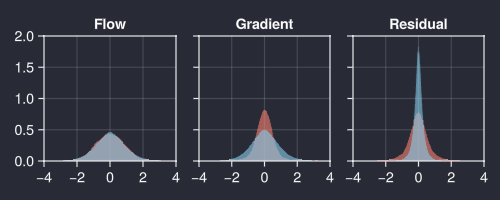

In [53]:
let
    fig = Figure(size=(500,200))
    titles = ["Flow", "Gradient", "Residual"]
    values = [ddh.w, -ddh.d0*ddh.u, ddh.w+ddh.d0*ddh.u]/sqrt(mean(abs2.(ddh.w)))
    valuesf = [fucci.w, -fucci.d0*fucci.u, fucci.w+fucci.d0*fucci.u]/sqrt(mean(abs2.(fucci.w)))
    n2s = norm.(values).^2
    @show (n2s[2:3]/n2s[1])
    axs = [Axis(fig[1,i],title=titles[i]) for i in 1:3]
    #[hist!(axs[i], values[i], bins=200, color=:skyblue, normalization=:pdf, rasterize=2) for i in 1:3]
    [density!(axs[i], valuesf[i], color=(:salmon,0.6)) for i in 1:3]
    [density!(axs[i], values[i], color=(:skyblue,0.6)) for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in 2:3]
    xlims!.(axs,-4,4)
    ylims!.(axs,0,2)
    linkaxes!(axs...)
    fig
end

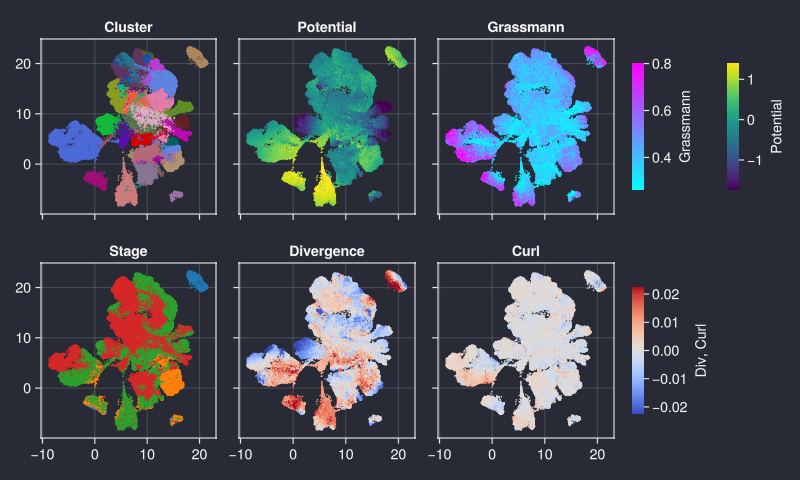

In [54]:
fig = let ms = 2, clp = 0.01
    #speeds = norm.(eachcol(V))
    ppal = Dict(zip(levels(adata.obs.stage),resample_cmap(:tab10,10)))
    #fig = Figure(size=(1000,600))
    fig = Figure(size=(800,480))
    #titles = ["Cluster w/ stream", "Potential", "Grassmann", "Speed", "Divergence", "Curl"]
    titles = ["Cluster", "Potential", "Grassmann", "Stage", "Divergence", "Curl"]
    axs = [Axis(fig[divrem(i-1,3).+1...],title=titles[i],aspect=1) for i in 1:length(titles)]
    scatter!(axs[1], pts, markersize=ms, color=[cpal[c] for c in cats],rasterize=2)
    #stream!(axs[1],gridsize=(40,40),arrow_size=8)
    pltu = scatter!(axs[2], pts, color=clip(ddh.u,clp), colormap=:viridis, markersize=ms,rasterize=2)
    pltg = scatter!(axs[3],pts,color=clip(ddh.vgrass,clp),markersize=ms,colormap=:cool,rasterize=1)
    #plts = scatter!(axs[4],pts, color=clip(speeds,clp), colormap=:plasma,markersize=ms,rasterize=2)
    plts = scatter!(axs[4],pts,markersize=ms,color=[ppal[c] for c in adata.obs.stage], rasterize=2)
    vmax = clipmax([ddh.div;ddh.rot],p=clp)
    pltd = scatter!(axs[5], pts, color=ddh.div, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax),rasterize=2)
    scatter!(axs[6], pts, color=ddh.rot, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax),rasterize=2)
    Colorbar(fig[1,4],pltg,label="Grassmann",height=Relative(0.7))
    Colorbar(fig[1,5],pltu,height=Relative(0.7),label="Potential")
    Colorbar(fig[2,4],pltd,height=Relative(0.7),label="Div, Curl")
    #Colorbar(fig[2,5],plts,height=Relative(0.7),label="Speed",vertical=true)
    [axs[i].xticklabelsvisible = false for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in [2,3,5,6]]
    linkaxes!(axs...)
    fig
end

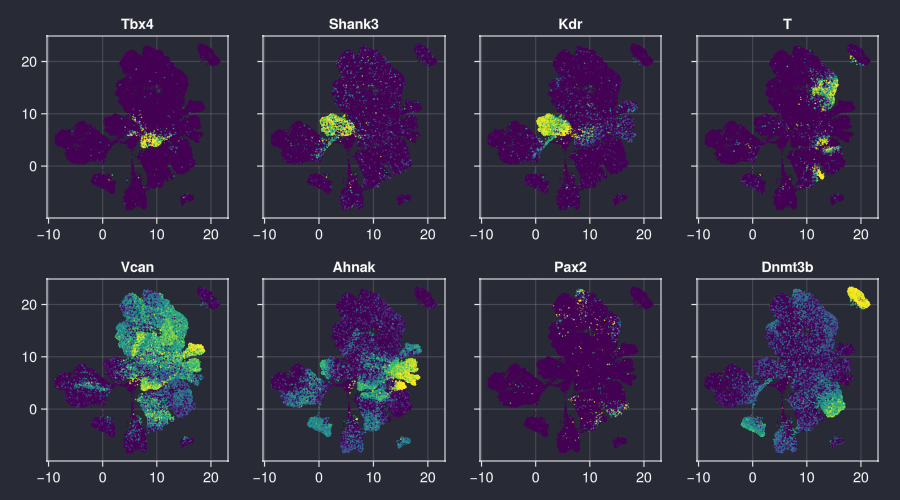

In [55]:
let ms=2, thr=0.01, cmap=:viridis
    genes = ["Tbx4","Shank3","Kdr","T","Vcan","Ahnak","Pax2","Dnmt3b"]
    n = length(genes)
    fig = Figure(size=(900,500))
    axs = [Axis(fig[divrem(i-1,4).+1...],title=genes[i],aspect=1) for i in 1:n]
    idxs = indexin(genes,adata.var_names)
    for i in 1:n
        expr = collect(adata.X[:,idxs[i]])
        plt=scatter!(axs[i],pts,color=clip(expr,thr),markersize=ms,colormap=cmap,rasterize=2)
        #Colorbar(fig[i+1],plt,vertical=false,flipaxis=false)
    end
    [axs[i].yticklabelsvisible=false for i in [2,3,4,6,7,8]]
    linkaxes!(axs...)
    fig
end

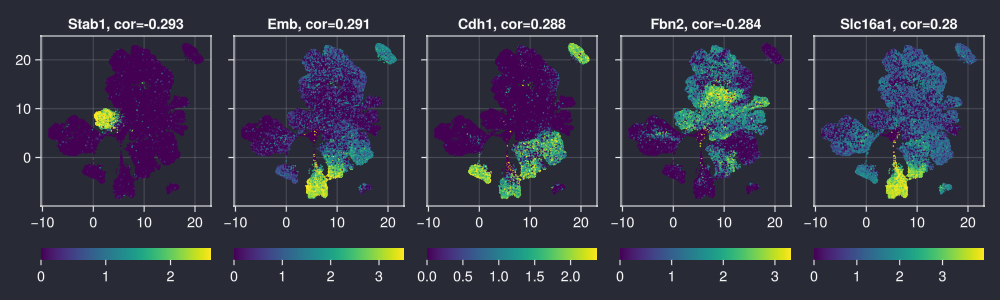

In [56]:
let vals=ddh.div, thr=0.01, ms=2, cmap=:viridis
    cc = vec(cor(adata.X,vals))
    idx = sortperm(abs.(cc);rev=true)[1:5]
    genes = adata.var_names[idx]
    corrs = round.(cc[idx],digits=3)
    n = length(genes)
    idxs = indexin(genes,adata.var_names)
    fig = Figure(size=(1000,300))
    axs = [Axis(fig[1,i],title="$(genes[i]), cor=$(corrs[i])",aspect=1) for i in 1:n]
    for i in 1:n
        expr = collect(adata.X[:,idxs[i]])
        plt=scatter!(axs[i],pts,color=clip(expr,thr),markersize=ms,colormap=cmap,rasterize=2)
        Colorbar(fig[2,i],plt,vertical=false,flipaxis=false)
    end
    [axs[i].yticklabelsvisible=false for i in 2:n]
    linkaxes!(axs...)
    fig
end

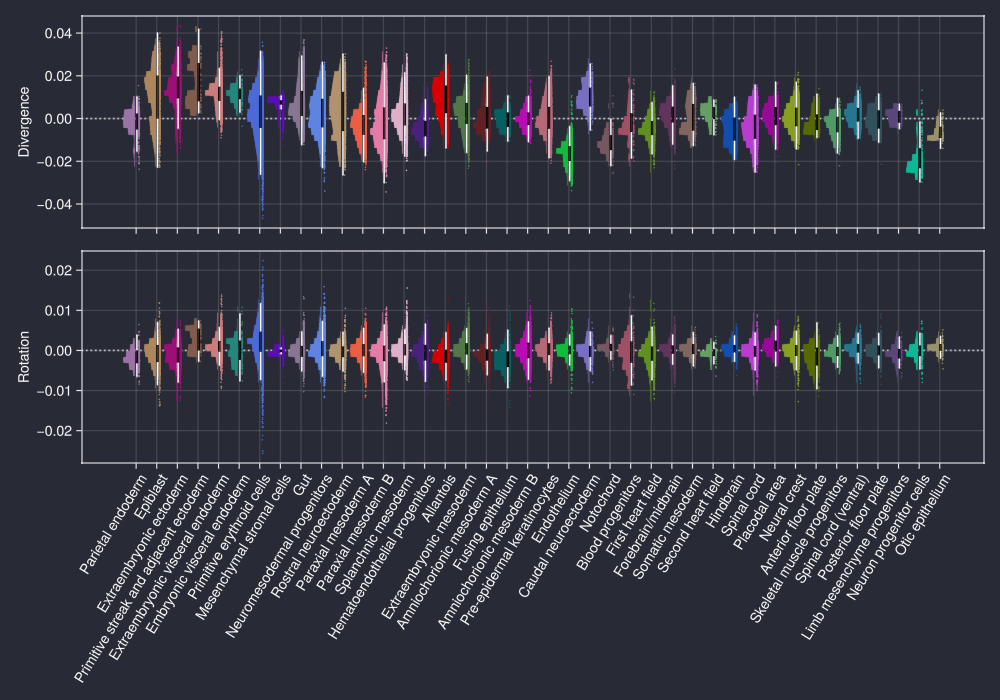

In [57]:
let
    fig = Figure(size=(1000,700))
    ax1 = Axis(fig[1,1],xticklabelrotation=45.0,ylabel="Divergence")
    ax2 = Axis(fig[2,1],xticklabelrotation=45.0,ylabel="Rotation")
    hlines!(ax1, [0], color=:lightgrey, linestyle=:dot)
    rainclouds!(ax1, string.(cats), ddh.div, color=[cpal[c] for c in cats],clouds=hist,rasterize=2)
    hlines!(ax2, [0], color=:lightgrey, linestyle=:dot)
    rainclouds!(ax2, string.(cats), ddh.rot, color=[cpal[c] for c in cats],clouds=hist,rasterize=2)
    ax1.xticklabelsvisible=false
    ax1.xticks=1:length(unique(cats))
    ax2.xticks=(1:length(unique(cats)),unique(string.(cats)))
    linkxaxes!(ax1,ax2)
    fig
end

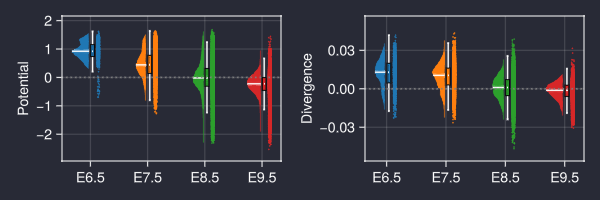

In [58]:
let
    labs = adata.obs.stage #phase
    cpal = resample_cmap(:tab10,10)
    fig = Figure(size=(600,200))
    #ax = Axis(fig[1,1],ylabel="Rotation")
    titles = ["Potential", "Divergence"]
    tval = @views [ddh.u,ddh.div]
    axs = [Axis(fig[1,i],ylabel=titles[i]) for i in 1:2]
    cols = cpal[indexin(adata.obs.stage,levels(adata.obs.stage))]
    for i in 1:2
        rainclouds!(axs[i],string.(labs),tval[i],color=cols,rasterize=2)
        hlines!(axs[i],[0],color=:grey,linestyle=:dot)
        axs[i].xticks=(1:length(levels(labs)),levels(labs))
    end
    fig
end

## Canalization plots
Visualization of cell state stability in embryonic devlopment

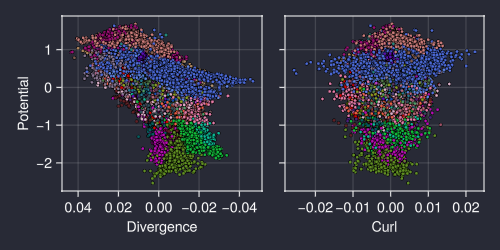

In [59]:
let ms = 4
    fig = Figure(size=(500,250))
    ax1 = Axis(fig[1,1],xlabel="Divergence",ylabel="Potential",xreversed=true)
    ax2 = Axis(fig[1,2],xlabel="Curl",yticklabelsvisible=false)
    [
        scatter!(
            ax, val, ddh.u, markersize=ms, rasterize=2,
            color=[cpal[c] for c in cats],strokewidth=0.5
        ) for (ax,val) = [(ax1,ddh.div),(ax2,ddh.rot)]
    ]
    #Legend(fig[1,3],[MarkerElement(marker=:circle,markersize=ms,strokewidth=0.5,color=cpal[p]) for p in lvs],lvs,nbanks=3,labelsize=11)
    fig
    #scatter(axs[2],ddh.rot,ddh.u,markersize=6,color=[cpal[c] for c in cats],strokewidth=0.5)
end

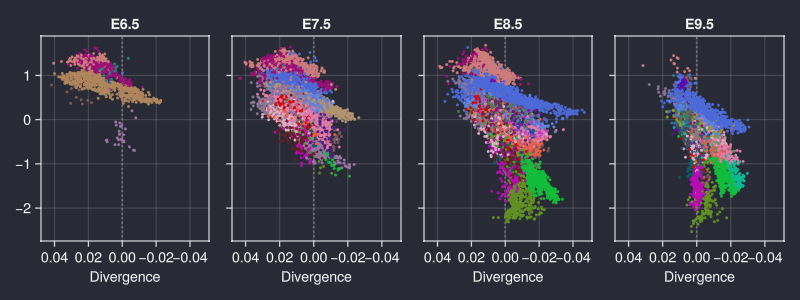

In [60]:
let
    #celltypes = ["Epiblast","Primitive streak and adjacent ectoderm","Splanchnic mesoderm","Paraxial mesoderm A","Paraxial mesoderm B","Skeletal muscle progenitors"]
    #celltypes = ["Epiblast","Primitive streak and adjacent ectoderm","Otic epithelium","Fusing epithelium","Placodal area","Pre-epidermal keratinocytes"]
    #isinc = [c ∈ celltypes for c in cats]
    isinc = fill(true,N)
    fig = Figure(size=(800,300))
    stages = ["E6.5","E7.5","E8.5","E9.5"]
    axs = [Axis(fig[1,i],xlabel="Divergence",title=stages[i],xreversed=true) for i in axes(stages,1)]
    for i in axes(stages,1)
        s = stages[i]
        idx = (adata.obs.stage .== s) .& isinc
        vlines!(axs[i],[0],linestyle=:dot,color=:grey)
        scatter!(
            axs[i],ddh.div[idx],ddh.u[idx],markersize=4,rasterize=2,
            color=[cpal[c] for c in cats[idx]],#strokewidth=0.5
        )
    end
    [axs[i].yticklabelsvisible=false for i in axes(stages,1)[2:end]]
    linkaxes!(axs...)
    fig
end

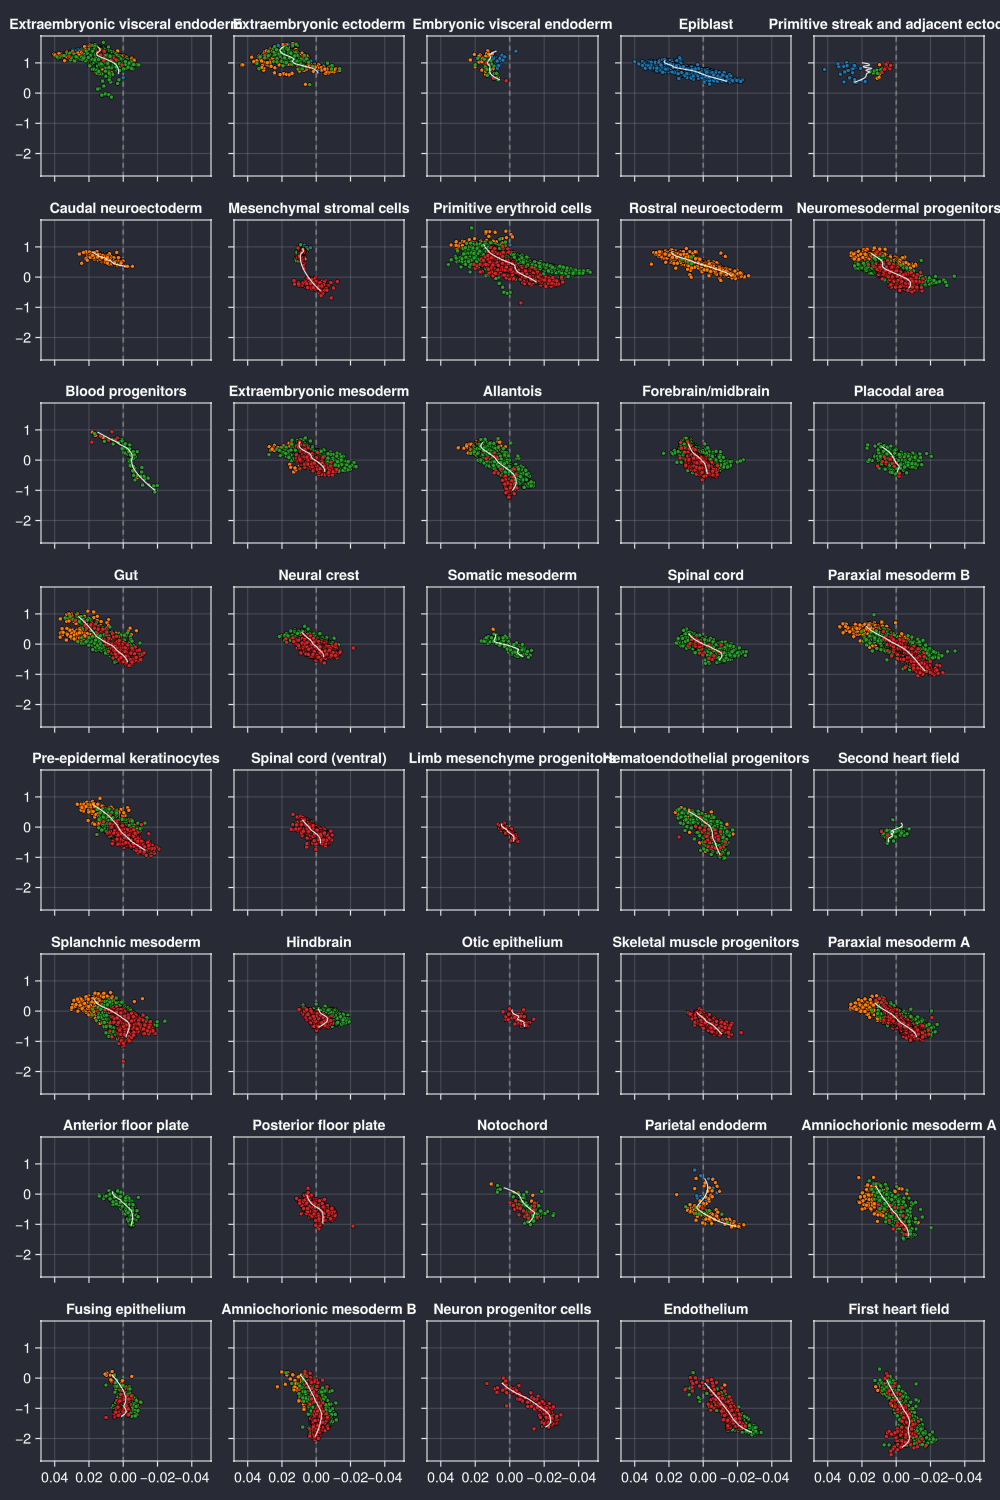

In [61]:
using StatsBase: quantile
import Loess
canals, fig = let
    stg = string.(adata.obs.stage)
    lvs = levels(adata.obs.stage)
    lvs = lvs[sortperm([parse(Float32,x[2:end]) for x in lvs])]
    spal = Dict(zip(lvs,resample_cmap(:tab10,10)))
    ncol = 5
    ft = freqtable(cats)
    ft = ft[ft.>30]
    levs = names(ft)[1]
    nlev = length(levs)
    avg = map(levs) do c
        idx = cats .== c
        sum(ddh.u[idx])/sum(idx)
    end
    levs = string.(levs[sortperm(avg,rev=true)])
    fig = Figure(size=(1000,1500))
    axs = ([Axis(fig[divrem(i-1,ncol).+1...],title=levs[i],xreversed=true) for i in 1:nlev])
    #axs = ([Axis(fig[divrem(i-1,ncol).+1...]) for i in 1:nlev])
    canals = Dict()
    for (i,c) in enumerate(levs)
        idx = cats .== c
        xs = ddh.div[idx]
        ys = ddh.u[idx]
        model = Loess.loess(ys,xs,span=0.5)
        us = LinRange(quantile(ys,0.01),quantile(ys,0.99),100)
        ps = Loess.predict(model,us)
        vlines!(axs[i],[0],color=:grey,linestyle=:dash)
        #scatter!(axs[i],ddh.div[idx],ddh.u[idx],transparency=true,markersize=2,color=cpal[c])
        #scatter!(axs[i],xs,ys,markersize=5,color=[(spal[s],0.33) for s in stgs[idx]])
        scatter!(axs[i],xs,ys,markersize=5,color=[spal[s] for s in stg[idx]],strokewidth=0.5,rasterize=2)
        lines!(axs[i],ps,us,color=:white,linewidth=1)
        canals[c] = Point2f.(ps,us)
    end
    [axs[i].yticklabelsvisible=false for i in findall(rem.(1:nlev,ncol) .!= 1)]
    [axs[i].xticklabelsvisible=false for i in 1:(div(nlev,ncol)-1)*ncol]
    linkaxes!(axs...)
    canals, fig
end
fig

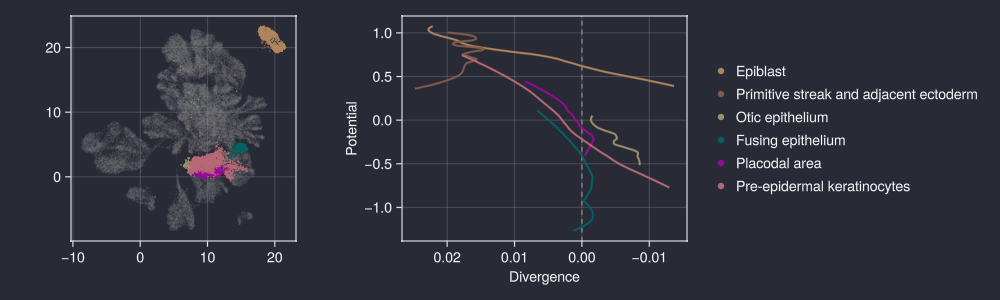

In [62]:
let
    #celltypes = ["Epiblast","Extraembryonic ectoderm","Extraembryonic visceral endoderm","Embryonic visceral endoderm","Parietal endoderm"]
    #celltypes = ["Epiblast","Primitive streak and adjacent ectoderm","Gut"]
    #celltypes = ["Epiblast","Primitive streak and adjacent ectoderm","Splanchnic mesoderm","Paraxial mesoderm A","Paraxial mesoderm B","Skeletal muscle progenitors"]
    #celltypes = ["Splanchnic mesoderm","Neural crest","Paraxial mesoderm A","Skeletal muscle progenitors","First heart field","Second heart field"]
    #celltypes = ["Epiblast","Rostral neuroectoderm","Primitive streak and adjacent ectoderm","Splanchnic mesoderm","First heart field","Second heart field","Paraxial mesoderm A"]
    #celltypes = ["Epiblast","Rostral neuroectoderm","Primitive streak and adjacent ectoderm","Neural crest","Spinal cord","Posterior floor plate","Neuron progenitor cells","Hindbrain","Posterior floor plate","Forebrain/midbrain"]
    #celltypes = ["Primitive streak and adjacent ectoderm","Caudal neuroectoderm","Rostral neuroectoderm","Neuromesodermal progenitors","Spinal cord","Paraxial mesoderm B"]
    #celltypes = ["Extraembryonic mesoderm","Allantois","Hematoendothelial progenitors","Endothelium","Blood progenitors","Primitive erythroid cells"]
    #celltypes = ["Splanchnic mesoderm","Neural crest","Paraxial mesoderm A","Skeletal muscle progenitors"]
    #celltypes = ["Epiblast","Primitive streak and adjacent ectoderm","Gut","Notochord"]
    #celltypes = ["Epiblast","Primitive streak and adjacent ectoderm","Blood progenitors","Allantois","Endothelium","Primitive erythroid cells","Hematoendothelial progenitors"]
    celltypes = ["Epiblast","Primitive streak and adjacent ectoderm","Otic epithelium","Fusing epithelium","Placodal area","Pre-epidermal keratinocytes"]
    #celltypes = unique(filter(x -> x.major_trajectory == "Epithelial_cells", adata.obs)[!,:qiu2022])
    #idx = [c ∈ celltypes for c in cats]
    # celltypes = let # all celltypes
    #   ft = freqtable(cats)
    #   names(ft[ft.>1000])[1]
    # end
    idx = [c ∈ celltypes for c in cats]
    fig = Figure(size=(1000,300))
    ax1 = Axis(fig[1,1],aspect=1)
    ax2 = Axis(fig[1,2],xlabel="Divergence",ylabel="Potential",xreversed=true)
    scatter!(ax1, pts, markersize=2,color=(:grey,0.1),rasterize=2)
    scatter!(ax1, pts[idx], markersize=2, color=[cpal[c] for c in cats[idx]],rasterize=2)
    vlines!(ax2,[0],color=:grey,linestyle=:dash)
    for c in celltypes
        lines!(ax2,canals[c],color=cpal[c],linewidth=2)
    end
    nbs = length(celltypes) > 12 ? 2 : 1
    Legend(fig[1,3],[MarkerElement(marker=:circle, color=cpal[c]) for c in celltypes],celltypes,nbanks=nbs)
    fig
end

## Point of interest

### Select cells of extrema in diverngence from each clusters

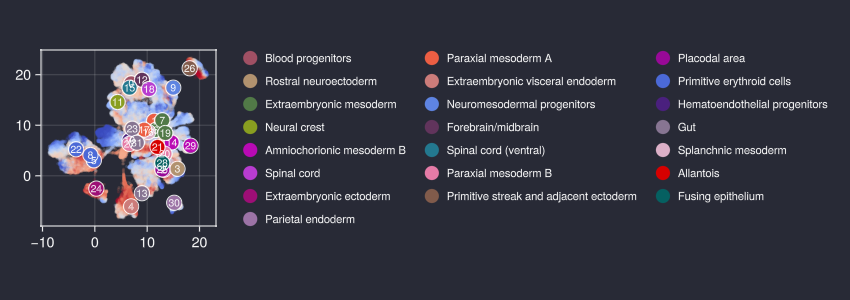

In [63]:
targetval = :div
elite = combine(
    sdf -> sdf[argmax(sdf[!,"ddh_$targetval"]),:], # max. targetval
    #sdf -> sdf[argmin(sdf[!,"ddh_$targetval"]),:], # min. targetval
    groupby([DataFrame(number=axes(adata.obs,1)) adata.obs],:clusters)
)

let thr=0.05, ms=20, shape=:circle, numcol=:white
    lvs = unique(string.(elite[!,anno]))
    vals = getfield(ddh,targetval)
    vmax = clipmax(vals,p=thr)
    fig = Figure(size=(850,300))
    ax = Axis(fig[1,1],aspect=1)
    scatter!(ax,pts,color=vals,alpha=0.2,markersize=4,colormap=:coolwarm,colorrange=(-vmax,vmax),rasterize=2)
    scatter!(ax,pts[elite.number],color=[cpal[c] for c in elite[!,anno]],marker=shape,markersize=20,strokewidth=1,strokecolor=:white)
    text!(ax,pts[elite.number],text=string.(elite.clusters),align=(:center,:center),fontsize=10,color=numcol)
    Legend(fig[1,2],[MarkerElement(marker=shape,markersize=ms, color=cpal[p]) for p in lvs],lvs,nbanks=3,labelsize=11)
    fig
end

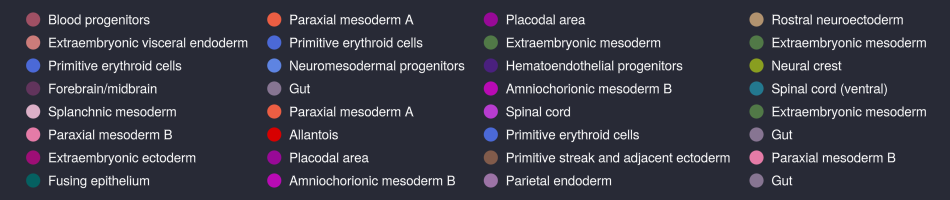

In [64]:
let
    fig = Figure(size=(950,200))
    lvs = string.(elite[!,anno])
    Legend(fig[1,1],[MarkerElement(marker=:circle, markersize=20, color=cpal[elite[i,anno]]) for i in axes(elite,1)],lvs,nbanks=4,labelsize=13)
    #save("test.pdf",fig)
    fig
end

In [65]:
sort(elite,"ddh_$targetval")[!,unique([:clusters,:ddh_div,:ddh_rot,anno])]

Row,clusters,ddh_div,ddh_rot,qiu2022
,String,Float64,Float64,String
1,29,0.00390342,0.00299522,Amniochorionic mesoderm B
2,28,0.0106716,-0.00771103,Fusing epithelium
3,23,0.0118514,-0.00432375,Gut
4,27,0.0129641,-3.57458e-5,Paraxial mesoderm B
5,10,0.0143357,-0.0040772,Hematoendothelial progenitors
6,1,0.0145184,0.00411495,Paraxial mesoderm A
7,15,0.0146607,-0.00439833,Spinal cord (ventral)
8,30,0.0154885,-0.00191199,Parietal endoderm
9,19,0.0155,-0.00570732,Extraembryonic mesoderm


### Select the dimensions of interest
Basis of J should be transformed to the original dimension before applying schur

In [66]:
targetcluster = "14"
targetcell = elite.number[findfirst(elite.clusters.==targetcluster)]
sf = let i = targetcell
    schur(basischange(ddh.J[i],ddh.frames[i],ddh.spans[i]))
end
svdf = sort(DataFrame(index=1:ddh.rdim,value=sf.values),order(:value,by=real,rev=true))

Row,index,value
,Int64,Float64
1,1,0.0204201
2,3,0.00621564
3,4,0.00172994
4,2,-0.00569385


In [67]:
let i = targetcell
    @show 0.5ddh.rot[i]
    @show imag.(eigvals(ddh.J[i]+ddh.H[i]))
    @show ddh.div[i], -tr(ddh.H[i])
    eigvals(basischange(ddh.J[i]+ddh.H[i],ddh.frames[i],ddh.planes[i]))
end

0.5 * ddh.rot[i] = 0.000989732497127629
imag.(eigvals(ddh.J[i] + ddh.H[i])) = [-0.0008113452628157495, 0.0008113452628157495, 0.0, 0.0]
(ddh.div[i], -(tr(ddh.H[i]))) = (0.022671847856324798, 0.022671847856324798)


2-element Vector{ComplexF64}:
 4.336808689942018e-19 - 0.0008113452628157489im
 4.336808689942018e-19 + 0.0008113452628157489im

### Project the target and the neighbors onto the invariant subspace

In [68]:
# target dimension to analyse (select by the eigvals above)
tdims = sort(svdf[isreal.(svdf.value),:index][1:2]) # shoud be sorted
#tdims = sort(svdf[isreal.(svdf.value),:index][end-1:end]) # shoud be sorted
@show tdims
#tdims = sort([1,2])
S, neis, xoi, voi = let i = targetcell, nnei = 1000, addvel = false
    svals, svecs = schurselect(sf,tdims)
    @show svals
    S = ddh.spans[i]*svecs # selected subspace
    # add velocity direction to last one
    addvel && (S = [ddh.spans[i]*ddh.spans[i]'V[:,i] S])
    if nnei > 0 # flag for select same cluster
        neis, = ddHodge.knn(kdtree,X[:,i],nnei,true)
    else
        neis = findall(adata.obs.clusters .== adata.obs.clusters[i])
        neis = neis[sortperm(norm.(eachcol(X[:,neis].-X[:,i])))]
    end
    xoi = S'*(X[:,neis].-X[:,i]) |> eachcol .|> Point2f
    voi = S'*V[:,neis] |> eachcol .|> Point2f
    (S, neis, xoi, voi)
end
length(neis)

tdims = [1, 3]
svals = [0.02042012029166293, 0.006215640447636954]


1000

### Which part was selected in UMAP

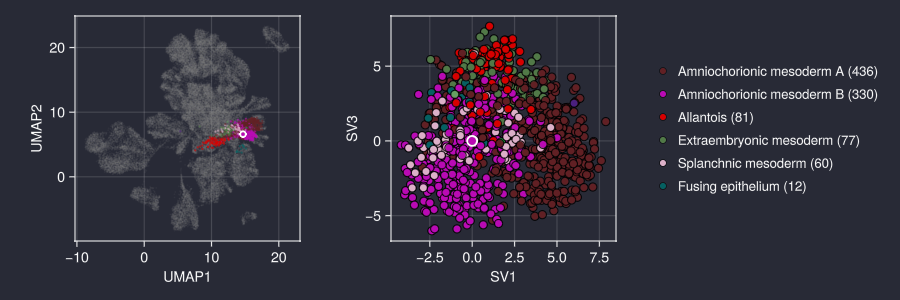

In [69]:
melm(c) = MarkerElement(marker=:circle, strokewidth=0.5, color=c)
fig = let i = targetcell
    cluster = lpad(adata.obs.clusters[i],2,'0')
    lvfreq = sort(freqtable(cats[neis]),rev=true)
    lvs = names(lvfreq[1:min(10,length(lvfreq))])[1] # show top 10 freq.
    lvs = lvs[lvfreq[lvs] .>= 2] # at least 2 cells
    labels = [string(lv)*" ($(lvfreq[lv]))" for lv in lvs]
    fig = Figure(size=(900,300))
    ax1 = Axis(fig[1,1],aspect=1,xlabel="UMAP1",ylabel="UMAP2")
    ax2 = Axis(fig[1,2],aspect=1,xlabel="SV$(tdims[1])",ylabel="SV$(tdims[2])")
    scatter!(ax1, pts, markersize=2, color=(:grey,0.1),rasterize=2)
    scatter!(ax1,pts[neis],markersize=3,color=[(cpal[c],0.6) for c in cats[neis]],rasterize=2)
    scatter!(ax1,pts[i],markersize=5,color=cpal[cats[i]],strokewidth=2,strokecolor=:white)
    scatter!(ax2,xoi,markersize=10,color=[cpal[c] for c in cats[neis]],strokewidth=1,rasterize=2)
    scatter!(ax2,xoi[1],markersize=11,color=cpal[cats[i]],strokewidth=2,strokecolor=:white)
    Legend(fig[1,3],[melm(cpal[p]) for p in lvs],labels,nbanks=1,labelsize=13)
    fig
end

## Top correlated genes expression in selected cells

Row,gene,Sall4,Nkx1.2,Unc5c,Amot,Lef1,Phlda2,Cdx2,Kit,Peg10,Ncl,Fzd10,Myc,Prtg,Npm1,Hs3st3b1,Il17rd,Trim71,Fgf3,Emb,Smtnl2
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,cor_div,0.450796,0.414025,0.408769,0.404654,0.383951,0.383832,0.381915,0.376801,0.370604,0.354044,0.353784,0.336719,0.336714,0.328796,0.324332,0.324036,0.321785,0.320605,0.304711,0.304148
2,cor_rot,0.057937,0.0875593,0.285243,0.027116,0.147714,0.107841,0.028074,0.119392,0.237045,0.00310675,0.0422476,-0.0140796,0.16465,0.0220999,-0.0178057,-0.0204617,0.0350049,0.132504,0.1409,0.0270016


Row,gene,Igf2,Col1a2,Tgfbr3,Serpinh1,Nnat,Plagl1,Smoc2,Col5a2,Svep1,Ahnak,Col5a1,Tek,Marcks,Dlk1,Myh10,Tmsb4x,Igfbp2,Anxa6,Slit2,Tspan9,Gas6
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,cor_div,-0.542394,-0.53708,-0.536551,-0.526827,-0.517689,-0.498527,-0.494305,-0.483068,-0.482498,-0.480179,-0.479182,-0.468017,-0.465496,-0.449699,-0.439167,-0.432847,-0.421227,-0.410287,-0.394295,-0.391103,-0.390416
2,cor_rot,-0.0848627,-0.0999564,-0.177988,-0.0672137,-0.238268,-0.151449,-0.22266,-0.117562,-0.0823528,0.0214469,-0.0557869,-0.0968598,-0.0825763,-0.0799762,-0.100244,0.0130084,0.0150422,-0.0817639,-0.171925,0.0320986,-0.160948


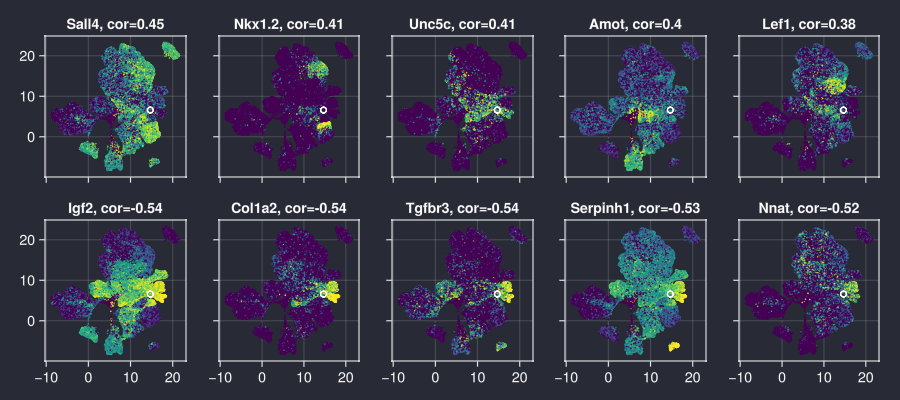

In [70]:
fig, topdf = let ms=2, thr=0.01, cmap=:viridis, topn=5, t=targetcell, val="cor_$targetval"
    pot = ddh.u[neis]
    div = ddh.div[neis]
    rot = ddh.rot[neis]
    # correlations in selected cells
    cor_div = vec(cor(adata.X[neis,:],div))
    cor_rot = vec(cor(adata.X[neis,:],rot))
    df = DataFrame(gene=adata.var_names,cor_div=cor_div,cor_rot=cor_rot)
    df = df[isfinite.(df.cor_div+df.cor_rot),:]
    r = sortperm(df[!,val],rev=true)
    display(permutedims(df[r[1:20],:],1))
    display(permutedims(df[reverse(r[end-20:end]),:],1))
    topdf = df[r[[1:topn; reverse(end-topn+1:end)]],:]
    genes = topdf.gene
    corrs = round.(topdf[!,val],digits=2)
    fig = Figure(size=(900,400))
    axs = [Axis(fig[divrem(i-1,topn).+1...],title="$(genes[i]), cor=$(corrs[i])",aspect=1) for i in 1:2topn]
    idx = indexin(genes,adata.var_names)
    for i in axes(axs,1)
        expr = collect(adata.X[:,idx[i]])
        plt = scatter!(axs[i],pts,color=clip(expr,thr),markersize=ms,colormap=cmap,rasterize=2)
        scatter!(axs[i],pts[t],markersize=5,color=:transparent,strokewidth=2,strokecolor=:white)
        #Colorbar(fig[i+1],plt,vertical=false,flipaxis=false)
        q, r = divrem(i-1,topn)
        q < 1 && (axs[i].xticklabelsvisible=false)
        r > 0 && (axs[i].yticklabelsvisible=false)
    end
    linkaxes!(axs...)
    fig, topdf
end
fig

## Hodge components in Schur subspace

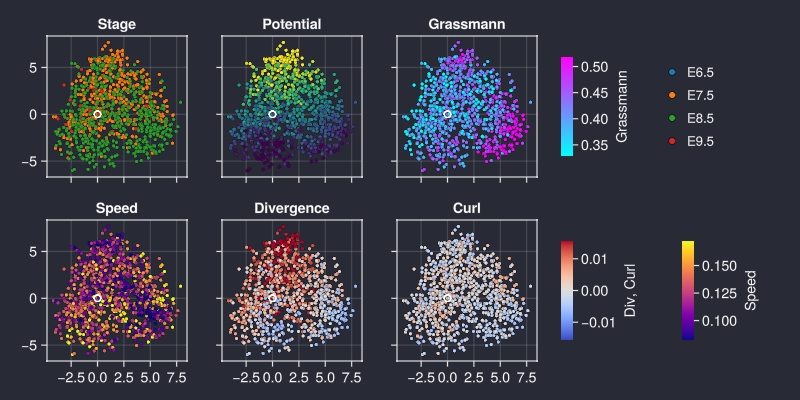

In [71]:
let i=targetcell, suse=tdims, ms=5, clp=0.05
    pot = ddh.u[neis]
    div = ddh.div[neis]
    rot = ddh.rot[neis]
    speeds = norm.(eachcol(V[:,neis]))
    vmax = clipmax([div;rot],p=clp)
    lvs = levels(adata.obs.stage)
    ppal = Dict(zip(lvs,resample_cmap(:tab10,10)))
    fig = Figure(size=(800,400))
    titles = ["Stage", "Potential", "Grassmann", "Speed", "Divergence", "Curl"]
    axs = [Axis(fig[divrem(i-1,3).+1...],title=titles[i],aspect=1) for i in 1:length(titles)]
    #scatter!(axs[1], xoi, markersize=ms, color=[cpal[c] for c in cats[nei]])
    pars = (markersize=ms,rasterize=2,transparency=false,strokewidth=0.2)
    scatter!(axs[1],xoi,color=[ppal[c] for c in adata.obs.stage[neis]];pars...)
    clipscatter!(ax,vals;args...) = scatter!(ax, xoi, color=clip(vals,clp);pars...,args...)
    pltu = clipscatter!(axs[2], pot, colormap=:viridis)
    pltg = clipscatter!(axs[3], ddh.vgrass[neis]; colormap=:cool)
    plts = clipscatter!(axs[4], speeds, colormap=:plasma)
    pltd = clipscatter!(axs[5], div, colormap=:coolwarm, colorrange=(-vmax,vmax))
    clipscatter!(axs[6], rot; colormap=:coolwarm, colorrange=(-vmax,vmax))
    for i in axes(axs,1)
        # point of interest
        scatter!(axs[i],xoi[1],markersize=ms+1,color=:transparent,strokewidth=2,strokecolor=:white)
    end
    Colorbar(fig[1,4],pltg,label="Grassmann",height=Relative(0.7))
    #Colorbar(fig[1,5],pltu,height=Relative(0.7),label="Potential")
    Colorbar(fig[2,4],pltd,height=Relative(0.7),label="Div, Curl")
    Colorbar(fig[2,5],plts,height=Relative(0.7),label="Speed",vertical=true)
    Legend(fig[1,5],[melm(ppal[p]) for p in lvs],lvs,labelsize=13)
    [axs[i].xticklabelsvisible = false for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in [2,3,5,6]]
    linkaxes!(axs...)
    fig
end

## Disect the dimension

### Top weights of genes in the Schur vectors

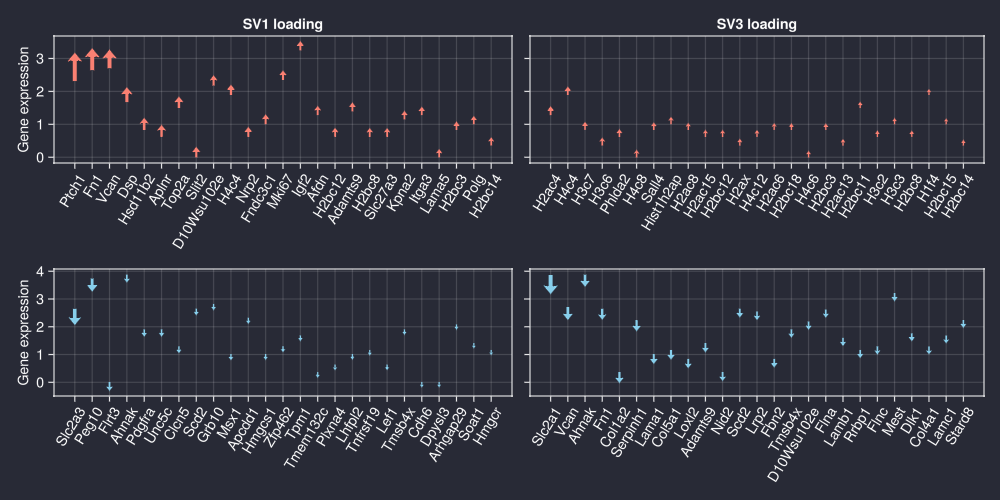

In [72]:
fig, wdf = let i=targetcell, topn=25, suse=tdims
    base = adata.X[i,:]
    W = loadings*S
    #W = S # if no PCA
    ranking = [sortperm(x,rev=true) for x in eachcol(W)]
    fig = Figure(size=(1000,500))
    axs = [Axis(fig[j,i],xticklabelrotation=45.0,) for i in 1:2 for j in 1:2]
    α = 3.0
    for j in 1:2
        for (i,c) in enumerate([:salmon,:skyblue])
            r = i==1 ? ranking[j] : reverse(ranking[j])
            locs = Point2f.(1:topn,base[r[1:topn]])
            arrs = α*Point2f.(fill(0,topn),W[r[1:topn],j])
            arrows2d!(axs[i+2*(j-1)],locs,arrs,color=c,shaftwidth=4)
            axs[i+2*(j-1)].xticks=(1:topn,adata.var_names[r[1:topn]])
        end
    end
    axs[1].title = "SV$(suse[1]) loading" #"s(t) + $α ∂s/∂X"
    axs[3].title = "SV$(suse[2]) loading" #"s(t) + $α ∂s/∂Y"
    colgap!(fig.layout,10)
    [axs[i].ylabel="Gene expression" for i in 1:2]
    [axs[i].yticklabelsvisible=false for i in 3:4]
    linkaxes!(axs[[1,3]]...)
    linkaxes!(axs[[2,4]]...)
    df = DataFrame(
        "names" => adata.var_names,
        "SV$(suse[1])" => W[:,1],
        "SV$(suse[2])" => W[:,2]
    )
    fig, df
end
fig

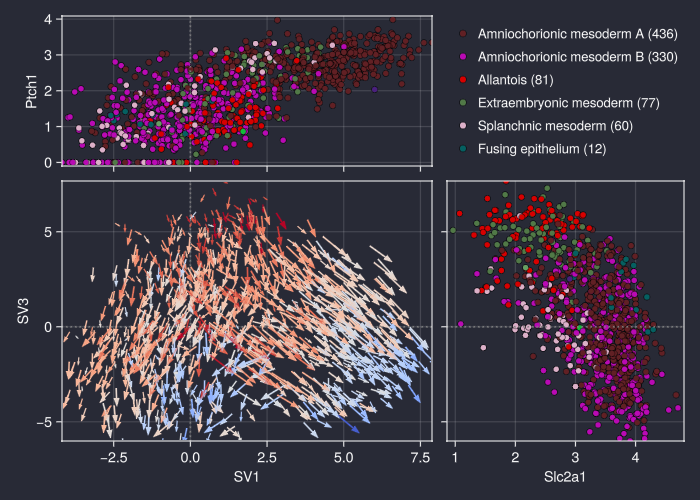

In [73]:
let i=targetcell, genex="Ptch1", geney="Slc2a1", ms=8, clp=0.01, cmap=:coolwarm #S
    #genex, geney = topdf.gene[[begin,end]] # top correlated genes
    exprx, expry = eachcol(adata.X[neis,indexin([genex,geney],adata.var_names)])
    # distance to the plane S
    #acol = sqrt.(vec(mapslices(norm,X[:,neis].-X[:,i],dims=1)).^2 - norm.(xoi).^2)
    #acol = [norm(X[:,neis[i]] - X[:,targetcell] - S*x) for (i,x) in enumerate(xoi)]
    #acol = (:white,0.6) #expr
    #acol = norm.(eachcol(V[:,neis]))
    acol = getfield(ddh,targetval)[neis]
    #acol = collect(exprx)
    #acol = maxlyap.(ddh.J[neis]).^-1
    #@show extrema(acol)
    cmax = clipmax(acol,p=clp)
    crange=(-cmax,cmax)
    #crange=(0,cmax)
    #@show crange
    pcol = [get(cpal,c,:lightgrey) for c in cats[neis]]
    lvfreq = sort(freqtable(cats[neis]),rev=true)
    lvs = names(lvfreq[1:min(7,length(lvfreq))])[1] # show top 10 freq.
    lvs = lvs[lvfreq[lvs] .>= 2] # at least 2 cells
    labels = [string(lv)*" ($(lvfreq[lv]))" for lv in lvs]
    W = loadings*S
    scpars = (;markersize=ms, rasterize=2, strokewidth=0.5, color=pcol)
    #fig = Figure(size=(480,360))
    fig = Figure(size=(700,500))
    #fig = Figure(size=(900,600))
    ax0 = Axis(fig[2,1],xlabel="SV$(tdims[1])",ylabel="SV$(tdims[2])")
    ax1 = Axis(fig[1,1],ylabel=genex,height=150)
    ax2 = Axis(fig[2,2],xlabel=geney,)#width=150)
    vlines!(ax0,[0],linestyle=:dot,color=:grey)
    hlines!(ax0,[0],linestyle=:dot,color=:grey)
    β = 1.5*maximum(norm.(voi))^-1
    #arrows2d!(ax0,xoi,β*voi,color=hsvmap(clip(exprx,clp),clip(expry,clp)),tipwidth=6,shaftwidth=0.2,transparency=false,rasterize=2)
    #arrows2d!(ax0,xoi,β*voi,color=:white,tipwidth=5,shaftwidth=0.2,transparency=false,rasterize=2)
    arrows2d!(ax0,xoi,β*voi,color=acol,colormap=cmap,colorrange=crange,tipwidth=6,shaftwidth=1.6,transparency=true,rasterize=2)
    #arr = arrows!(ax0,xoi,β*voi,color=acol,arrowsize=4,colormap=cmap,linewidth=0.8,colorrange=crange,rasterize=2)
    sc = scatter!(ax1,first.(xoi),exprx;scpars...)
    vlines!(ax1,[0],linestyle=:dot,color=:grey)
    xlims!(ax1,extrema(first.(xoi))...)
    ylims!(ax1,extrema(exprx).+[-0.1,0.1]...)
    scatter!(ax2,expry,last.(xoi);scpars...)
    hlines!(ax2,[0],linestyle=:dot,color=:grey)
    xlims!(ax2,extrema(expry).+[-0.1,0.1]...)
    ylims!(ax2,extrema(last.(xoi))...)
    linkxaxes!(ax0,ax1)
    linkyaxes!(ax0,ax2)
    ax1.xticklabelsvisible=false
    ax2.yticklabelsvisible=false
    #Colorbar(fig[2,3],arr,vertical=true,flipaxis=true)
    #Colorbar(fig[3,1],colormap=:hsv,vertical=false,flipaxis=false)
    leg = Legend(fig[1,2],[melm(cpal[p]) for p in lvs],labels,nbanks=1,labelsize=13,)
    #leg.tellwidth = true
    #leg.tellheight = true
    colgap!(fig.layout, 10)
    rowgap!(fig.layout, 10)
    fig
end

## Rank genes by clusters

In [74]:
function rankGenesDF(ad, group)
    keys = ["names","logfoldchanges","scores","pvals","pvals_adj"]
    DataFrame([k => [x[group] for x in vec(ad.uns["rank_genes_groups"][k])] for k in keys])
end

rgdf = rankGenesDF(adata,Symbol(targetcluster))
rgdf = [DataFrame(rank=1:size(rgdf,1)) sort(rgdf,:scores,rev=true)]

Row,rank,names,logfoldchanges,scores,pvals,pvals_adj
,Int64,String,Float32,Float32,Float64,Float64
1,1,Ahnak,134.356,63.0673,0.0,0.0
2,2,Pmp22,22.7806,61.9771,0.0,0.0
3,3,Stard8,20.1481,60.3443,0.0,0.0
4,4,Dlk1,22.3827,58.6185,0.0,0.0
5,5,Krt8,23.7853,57.612,0.0,0.0
6,6,Tbx20,14.2612,57.2166,0.0,0.0
7,7,Svep1,15.0668,56.7149,0.0,0.0
8,8,Hand1,10.7895,56.3223,0.0,0.0
9,9,Nrp1,15.5361,56.0169,0.0,0.0


highlight = 5×8 DataFrame
 Row │ names   SV1        SV3          rank   logfoldchanges  scores   pvals         pvals_adj
     │ String  Float64    Float64      Int64  Float32         Float32  Float64       Float64
─────┼────────────────────────────────────────────────────────────────────────────────────────────
   1 │ Fn1      0.215956  -0.122847       58         60.9736  45.3076  0.0           0.0
   2 │ Ptch1    0.279903  -0.00185069    106         26.6895  39.4368  0.0           0.0
   3 │ Vcan     0.181509  -0.145881      128         18.2499  37.7766  0.0           0.0
   4 │ Peg10   -0.149134   0.0129271     219         33.5361  33.5413  1.20606e-246  7.66923e-245
   5 │ Slc2a3  -0.186663  -0.0228128     798         12.5124  20.2468  3.79062e-91   6.55753e-90
highlight = 5×8 DataFrame
 Row │ names   SV1         SV3        rank   logfoldchanges  scores   pvals    pvals_adj
     │ String  Float64     Float64    Int64  Float32         Float32  Float64  Float64
─────┼─────────────────

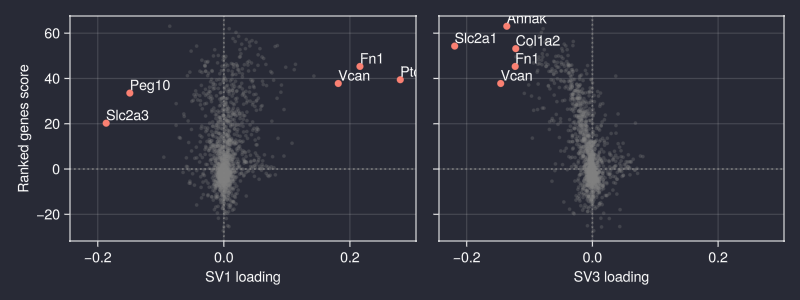

In [75]:
mdf = innerjoin(wdf,rgdf,on=:names)
let topn = 5
    fig = Figure(size=(800,300))
    axs = [Axis(fig[1,i],xlabel="SV$(tdims[i]) loading") for i in 1:2]
    axs[1].ylabel="Ranked genes score"
    for (i,toshow) in enumerate(["SV$k" for k in tdims])
        vals = mdf[!,toshow]
        scatter!(axs[i],vals,mdf.scores,markersize=5,color=(:grey,0.3),rasterize=2)
        highlight = mdf[invperm(sortperm(abs.(vals),rev=true)) .<= topn,:]
        @show highlight
        scatter!(axs[i],highlight[!,toshow],highlight.scores,markersize=10,color=:salmon,rasterize=2)
        for j in 1:size(highlight,1)
            text!(
                axs[i], Point2f(highlight[j,toshow],highlight.scores[j]),
                text = highlight.names[j], fontsize=14, #color=:white,
                align=(:left,:bottom)
            )
        end
    end
    axs[2].yticklabelsvisible=false
    hlines!.(axs,[0],linestyle=:dot,color=:grey)
    vlines!.(axs,[0],linestyle=:dot,color=:grey)
    linkxaxes!(axs...)
    linkyaxes!(axs...)
    fig
end

In [76]:
rgdf[indexin(topdf.gene,rgdf.names),:]

Row,rank,names,logfoldchanges,scores,pvals,pvals_adj
,Int64,String,Float32,Float32,Float64,Float64
1,10953,Sall4,-1.42727,-0.367958,0.712905,0.834758
2,7834,Nkx1.2,-0.503876,1.45568,0.145481,0.214048
3,352,Unc5c,7.25546,28.8812,2.05923e-183,8.14684e-182
4,1336,Amot,1.33998,15.6963,1.60239e-55,1.62764e-54
5,13605,Lef1,-0.859068,-6.27456,3.50631e-10,1.02711e-9
6,12,Igf2,79.126,54.5197,0.0,0.0
7,17,Col1a2,22.0886,53.1687,0.0,0.0
8,28,Tgfbr3,11.0621,49.477,0.0,0.0
9,27,Serpinh1,31.8111,49.578,0.0,0.0
